In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Seting the seed
np.random.seed(42)

# Load the dataset
df = pd.read_csv("../data/processed/macro_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Only use GDP for LSTM prediction
gdp_data = df[['GDP']].copy()

# Normalize GDP
scaler = MinMaxScaler()
scaled_gdp = scaler.fit_transform(gdp_data)

# Sequence creation
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 4  # use 4 quarters (1 year)
X, y = create_sequences(scaled_gdp, SEQ_LEN)

# Split into train, val, test (70%, 15%, 15%)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(SEQ_LEN, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train, epochs=100, batch_size=4,
                    validation_data=(X_val, y_val), verbose=0)

# Predict on test set
y_pred = model.predict(X_test)

# Inverse transform predictions
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# Evaluate
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("\n LSTM Results on Test Set:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")





In [ ]:
SEQ_LEN = 4
n = len(df) - SEQ_LEN
train_idx = int(n * 0.7)
val_idx = int(n * 0.15)
test_idx_start = train_idx + val_idx + SEQ_LEN
test_dates = df.index[test_idx_start:test_idx_start + len(y_test_inv)]


actual = pd.Series(y_test_inv.flatten(), index=test_dates)
predicted = pd.Series(y_pred_inv.flatten(), index=test_dates)


plt.figure(figsize=(12, 6))
plt.plot(actual.index, actual, label='Actual GDP', color='blue', linewidth=2)
plt.plot(predicted.index, predicted, label='Forecasted GDP', linestyle='--', color='red', linewidth=2)
plt.title('LSTM Model Forecast vs Actual GDP', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('GDP Growth Rate', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


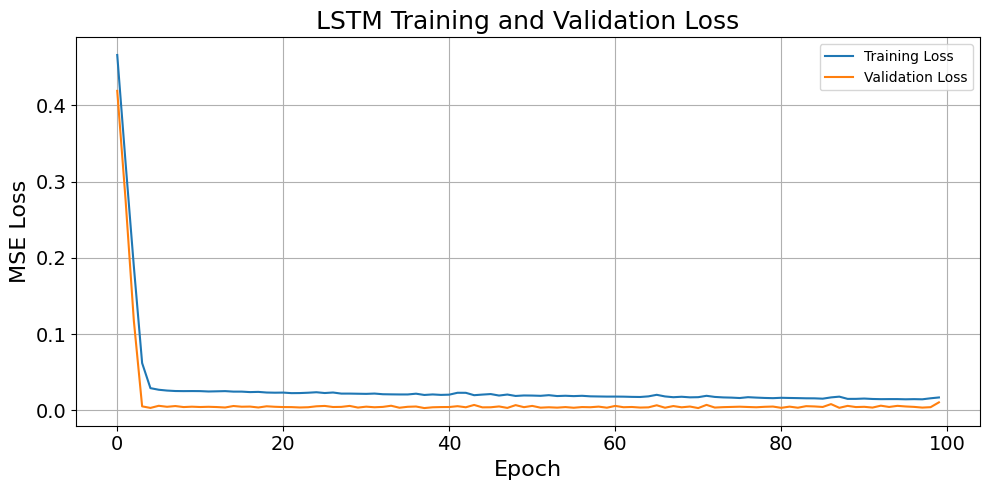

In [ ]:
# Plot training and val loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss', fontsize=18)
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('MSE Loss', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

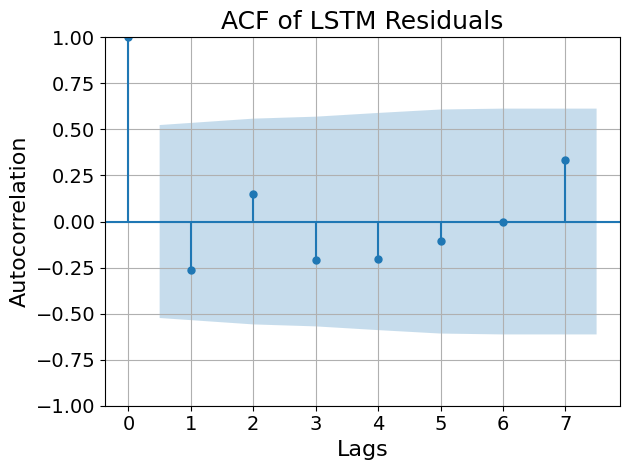

<Figure size 1000x600 with 0 Axes>

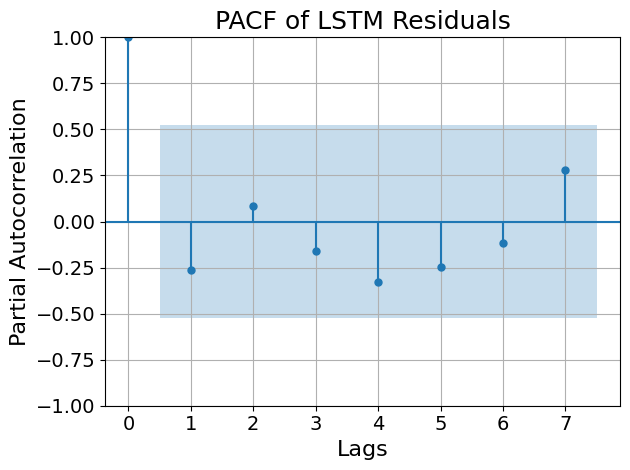

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Calculate residuals
residuals = y_test_inv.flatten() - y_pred_inv.flatten()

# Determine valid lag count
max_lags = len(residuals) // 2

# ACF plot
plt.figure(figsize=(10, 6))
plot_acf(residuals, lags=max_lags)
plt.title("ACF of LSTM Residuals", fontsize=18)
plt.xlabel("Lags", fontsize=16)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# PACF plot
plt.figure(figsize=(10, 6))
plot_pacf(residuals, lags=max_lags)
plt.title("PACF of LSTM Residuals", fontsize=18)
plt.xlabel("Lags", fontsize=16)
plt.ylabel("Partial Autocorrelation", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Save the results for comparison
lstm_forecast_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_GDP': y_test_inv.flatten(),
    'LSTM_Forecast': y_pred_inv.flatten()
})


#lstm_forecast_df.to_csv('lstm_forecast_results.csv', index=False)
